In [48]:
from dotenv import load_dotenv
load_dotenv()

import os

import numpy as np
from pixell import enmap, enplot, reproject
import glob
import matplotlib.pyplot as plt
import emcee, corner
from astropy.io import fits
import sys
from astropy import units as u, constants as const
sys.path.insert(0, '../src')
#sys.path.insert(0, "/home/gill/apps/szpack/python")
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
import yaml
import itertools
from pixell import enmap

import bandpass as bp
import covariance as cov
import model
import utils as ut

import SZpack as SZ

from astropy.coordinates import SkyCoord
import astropy.units as u

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
cf_path = "../configs/case50_ajay.yaml"
cf = ut.get_config_file(f'{cf_path}')

In [81]:
region = ut.get_region(cf['region_center_ra'], 
                        cf['region_center_dec'], 
                        cf['region_width'])
dire_data = "/home/gill/research/ACT/bridge/data_paper/data/data/act_no_reproj"
data_ref = ut.imap_dim_check(enmap.read_map(f"{dire_data}/act_cut_dr6v2_pa5_f150_4way_coadd_map_srcfree.fits", 
                        box=region)) 

model_map = ut.imap_dim_check(enmap.read_map("/home/gill/research/ACT/paper/models/indiv/aug17/total_model_all_three_systems_small_map/models/bridge_indv_150_pa5_model_uK.fits",
                        box=region))

apod_mask = (enmap.apod(data_ref*0+1, cf['apod_pix']))
# apod_mask = 1
mean_apod_mask = np.mean(apod_mask)

data_ref = data_ref * apod_mask
model_map = model_map * apod_mask

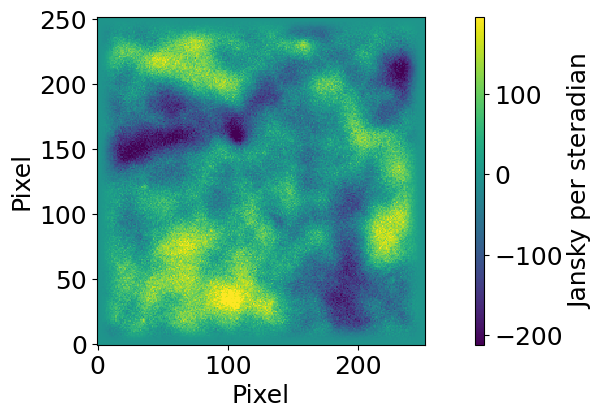

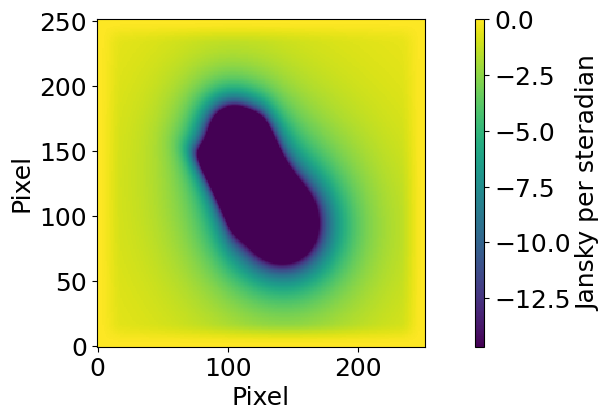

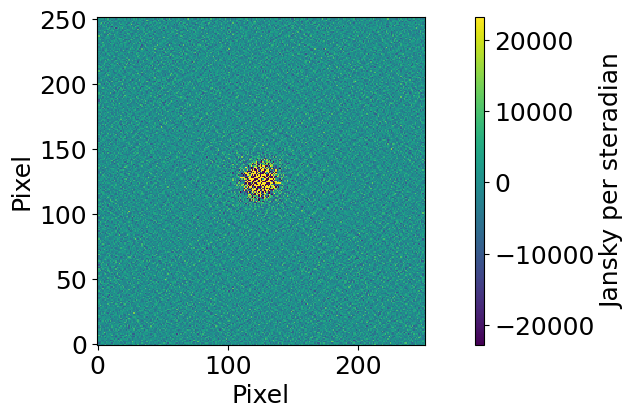

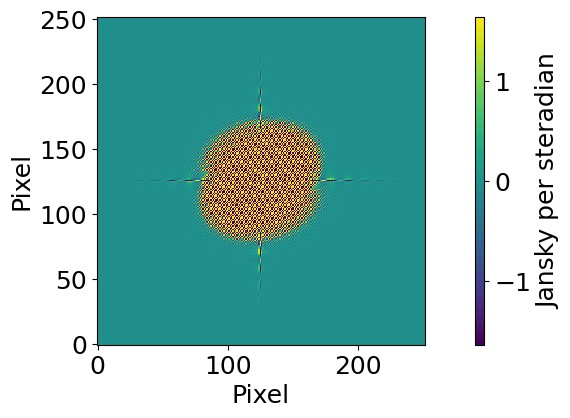

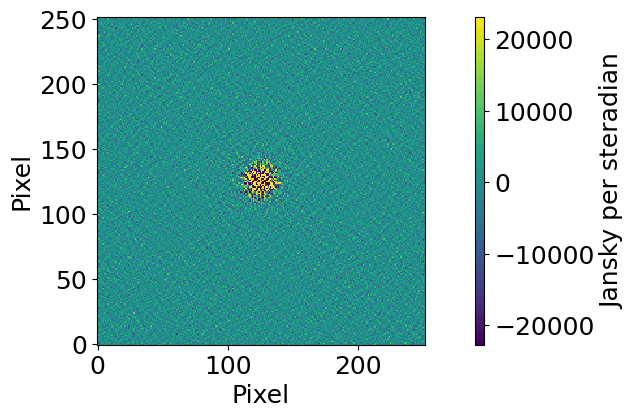

In [82]:
data_ref_fft = np.fft.fftshift(np.fft.fft2(data_ref)) / mean_apod_mask
model_fft = np.fft.fftshift(np.fft.fft2(model_map))  / mean_apod_mask

ut.plot_image(data_ref, interval_type="zscale")
ut.plot_image(model_map, interval_type="zscale")

ut.plot_image(data_ref_fft.real, interval_type="zscale")
ut.plot_image(model_fft.real, interval_type="zscale")

diff = data_ref_fft - model_fft
ut.plot_image(diff.real, interval_type="zscale")